In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('train_energy_data.csv')
test_df = pd.read_csv('test_energy_data.csv')
train_df.head()


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [4]:
train_df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [5]:
train_df.describe(include="O")

,Building Type,Day of Week
count,1000,1000
unique,3,2
top,Residential,Weekday
freq,347,507


In [6]:
train_df.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [7]:
train_df.duplicated().sum()

np.int64(0)

In [8]:
train_df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [9]:
train_df['Day of Week'].value_counts()

,count
Day of Week,
Weekday,507
Weekend,493


In [10]:
train_df['Building Type'].value_counts()

,count
Building Type,
Residential,347
Commercial,336
Industrial,317


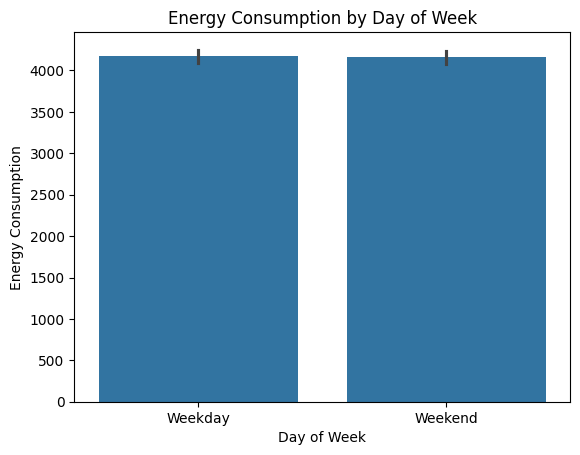

In [11]:
sns.barplot(x='Day of Week', y='Energy Consumption', data=train_df)
plt.title('Energy Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Energy Consumption')
plt.show()

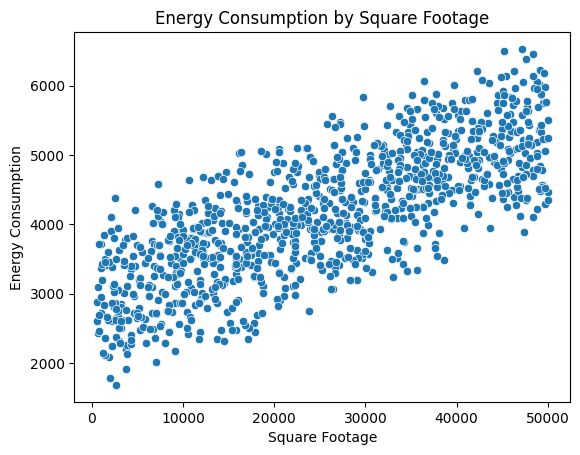

In [12]:
sns.scatterplot(x='Square Footage', y='Energy Consumption', data=train_df)
plt.title('Energy Consumption by Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Energy Consumption')
plt.show()


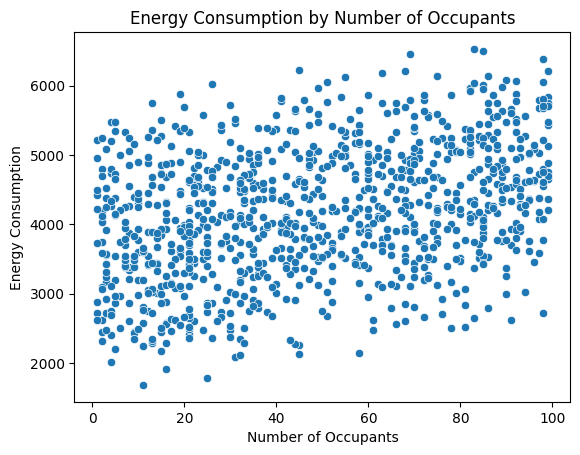

In [13]:
sns.scatterplot(x='Number of Occupants', y='Energy Consumption', data=train_df)
plt.title('Energy Consumption by Number of Occupants')
plt.xlabel('Number of Occupants')
plt.ylabel('Energy Consumption')
plt.show()

## Feature Engineering



In [14]:
print('Zero Occupants:', (train_df['Number of Occupants'] == 0).sum())
print('Zero Square Footage:', (train_df['Square Footage'] == 0).sum())
print('Zero Occupants (test):', (test_df['Number of Occupants'] == 0).sum())
print('Zero Square Footage (test):', (test_df['Square Footage'] == 0).sum())

Zero Occupants: 0
Zero Square Footage: 0
Zero Occupants (test): 0
Zero Square Footage (test): 0


In [15]:
train_df['Occupants_per_sqft'] = train_df['Number of Occupants'] / train_df['Square Footage']
train_df['Appliances_per_person'] = train_df['Appliances Used'] / train_df['Number of Occupants']

test_df['Occupants_per_sqft'] = test_df['Number of Occupants'] / test_df['Square Footage']
test_df['Appliances_per_person'] = test_df['Appliances Used'] / test_df['Number of Occupants']

train_df[['Occupants_per_sqft', 'Appliances_per_person']].describe()

,Occupants_per_sqft,Appliances_per_person
count,1000.000000,1000.000000
mean,0.004017,1.368658
std,0.008063,3.035218
min,0.000021,0.010526
25%,0.000959,0.290404
50%,0.001942,0.528595
75%,0.003628,1.142857
max,0.121429,28.000000


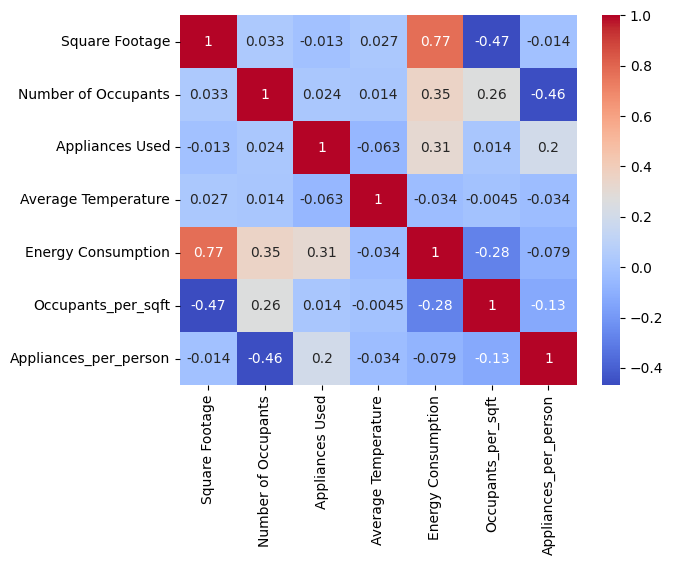

Energy Consumption       1.000000
Square Footage           0.774873
Number of Occupants      0.354485
Appliances Used          0.312792
Average Temperature     -0.034487
Appliances_per_person   -0.078656
Occupants_per_sqft      -0.280329
Name: Energy Consumption, dtype: float64


In [16]:
corr = train_df.select_dtypes(include=("int64","float64")).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

print(corr['Energy Consumption'].sort_values(ascending=False))

In [17]:
X_train=train_df.drop('Energy Consumption',axis=1)
y_train=train_df['Energy Consumption']

X_test=test_df.drop('Energy Consumption',axis=1)
y_test=test_df['Energy Consumption']

In [18]:
num_cols=['Square Footage','Number of Occupants','Average Temperature','Appliances Used',
          'Occupants_per_sqft','Appliances_per_person']
cat_cols=['Day of Week','Building Type']

In [19]:
from sklearn.preprocessing import StandardScaler
scaller=StandardScaler()
X_train[num_cols]=scaller.fit_transform(X_train[num_cols])
X_test[num_cols]=scaller.transform(X_test[num_cols])

In [20]:
X_train=pd.get_dummies(X_train,columns=cat_cols,drop_first=True)
X_test=pd.get_dummies(X_test,columns=cat_cols,drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [21]:
from sklearn.linear_model import LinearRegression
reg_model=LinearRegression()
reg_model.fit(X_train,y_train)

LinearRegression()

In [22]:
reg_model.score(X_train,y_train)

0.999999999785923

In [23]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(reg_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}, Std: {cv_scores.std():.6f}")

CV R² scores: [1. 1. 1. 1. 1.]
Mean: 1.0000, Std: 0.000000


In [24]:
y_pred = reg_model.predict(X_test)

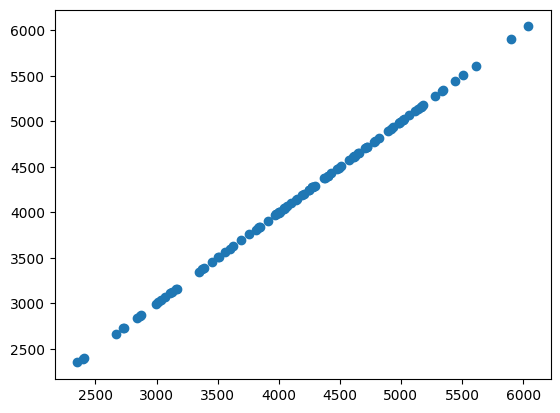

In [25]:
plt.scatter(y_test, y_pred)

In [26]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MSE : 0.00
RMSE: 0.01
R²  : 1.000


In [27]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": reg_model.coef_
})

coef.sort_values("Coefficient")

,Feature,Coefficient
8,Building Type_Residential,-500.000179
6,Day of Week_Weekend,-50.000769
3,Average Temperature,-35.682189
4,Occupants_per_sqft,0.000074
5,Appliances_per_person,0.000155
2,Appliances Used,281.962491
1,Number of Occupants,290.474512
7,Building Type_Industrial,500.000491
0,Square Footage,714.370094


In [28]:
reg_model.intercept_

np.float64(4205.902855274606)

In [29]:
print(r2_score(y_test, y_pred))

0.9999999997054334


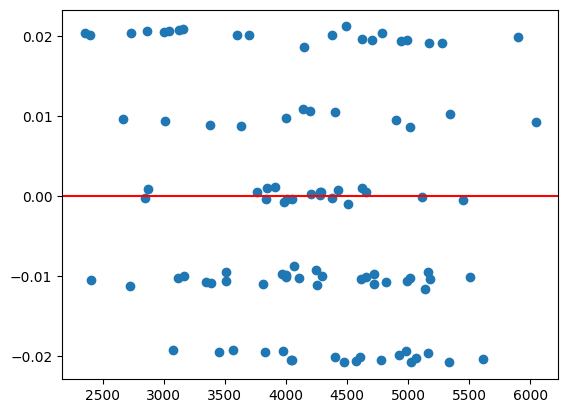

In [30]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')

In [31]:
train_df.groupby('Building Type')['Energy Consumption'].std()
train_df['Square Footage'].corr(train_df['Energy Consumption'])

np.float64(0.774872594798946)

FROM SCRATCH MODEL

In [32]:
import numpy as np

def linear_regression_gd(X, y, eta=0.1, n_iterations=1000):

    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    y = y.values.reshape(-1, 1) if hasattr(y, "values") else y.reshape(-1, 1)

    theta = np.random.randn(X_b.shape[1], 1)
    loss_history = []

    for iteration in range(n_iterations):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients

        loss = np.mean((X_b.dot(theta) - y) ** 2)
        loss_history.append(loss)

    return theta, loss_history

def predict_gd(X, theta):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]
    return X_b.dot(theta).flatten()

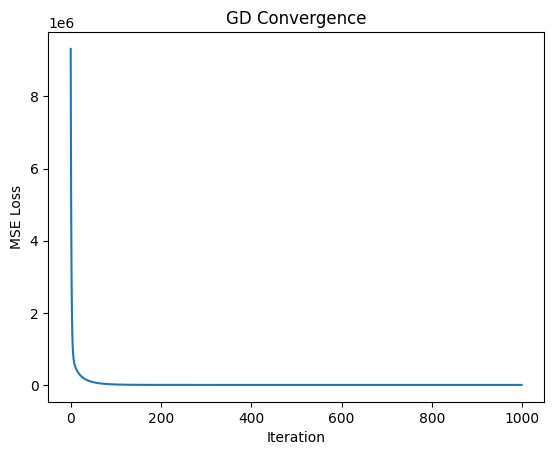

In [33]:
theta_scratch, losses = linear_regression_gd(X_train, y_train, eta=0.1, n_iterations=1000)

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("GD Convergence")
plt.show()

y_pred_scratch = predict_gd(X_test, theta_scratch)

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

mse_sklearn = mean_squared_error(y_test, y_pred)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test, y_pred)

mse_scratch = mean_squared_error(y_test, y_pred_scratch)
rmse_scratch = np.sqrt(mse_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)

comparison = pd.DataFrame({
    "Model": ["Sklearn (built-in)", "From Scratch (GD)"],
    "MSE": [mse_sklearn, mse_scratch],
    "RMSE": [rmse_sklearn, rmse_scratch],
    "R2": [r2_sklearn, r2_scratch]
})
comparison

,Model,MSE,RMSE,R2
0,Sklearn (built-in),0.000202,0.014218,1.0
1,From Scratch (GD),0.000202,0.014218,1.0


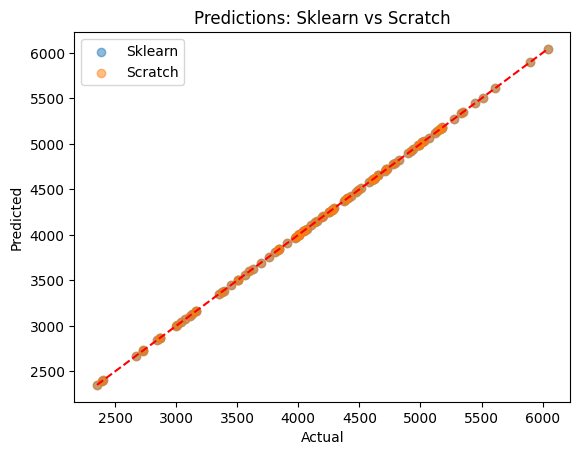

In [35]:
plt.scatter(y_test, y_pred, alpha=0.5, label='Sklearn')
plt.scatter(y_test, y_pred_scratch, alpha=0.5, label='Scratch')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.title("Predictions: Sklearn vs Scratch")
plt.show()

In [36]:
print(X_train.columns.tolist())
print(y_train.describe())
print(y_pred[:5], y_test[:5].values)

['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Occupants_per_sqft', 'Appliances_per_person', 'Day of Week_Weekend', 'Building Type_Industrial', 'Building Type_Residential']
count    1000.000000
mean     4166.252570
std       933.313064
min      1683.950000
25%      3509.482500
50%      4175.730000
75%      4863.850000
max      6530.600000
Name: Energy Consumption, dtype: float64
[2865.5493332  4283.79951578 5067.85025468 4624.29900376 4820.60073626] [2865.57 4283.8  5067.83 4624.3  4820.59]


In [37]:
import joblib, pickle

joblib.dump(reg_model, 'sklearn_model.pkl')

metrics = {
    "sklearn": {"MSE": mse_sklearn, "RMSE": rmse_sklearn, "R2": r2_sklearn},
    "scratch": {"MSE": mse_scratch, "RMSE": rmse_scratch, "R2": r2_scratch}
}

coef_dict = dict(zip(X_train.columns, reg_model.coef_))

scratch_model = {
    'theta': theta_scratch,
    'scaler': scaller,
    'columns': X_train.columns.tolist(),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'loss_history': losses,
    'metrics': metrics,
    'coef_dict': coef_dict,
    'intercept': reg_model.intercept_
}
with open('scratch_model.pkl', 'wb') as f:
    pickle.dump(scratch_model, f)

print("Saved successfully")

Saved successfully


In [38]:
from google.colab import files
files.download('sklearn_model.pkl')
files.download('scratch_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>